<a href="https://colab.research.google.com/github/rtajeong/M4_2026/blob/main/lab_65_superstore_ARIMA_rev5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ARIMA Model for Time Series data
- 슈퍼마켓 매출 예측
- 가구 세일 데이터 사용
- download from:
https://community.tableau.com/s/question/0D54T00000CWeX8SAL/sample-superstore-sales-excelxls


In [3]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

- you can download the data from https://vizlab.tistory.com/122.
- about 3.2 MB (If size causes problems, you can convert it to a .csv file.)

## Data

In [4]:
df = pd.read_excel("Lab_65_Superstore.xls")
pd.concat([df.head(3), df.tail(3)])

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960,2,0.0,41.9136
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.940,3,0.0,219.5820
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,0.0,6.8714
9991,9992,CA-2018-121258,2018-02-26,2018-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627.0,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2018-121258,2018-02-26,2018-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627.0,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2018-119914,2018-05-04,2018-05-09,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683.0,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [5]:
df.shape, df.columns

((9994, 21),
 Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
        'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
        'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
        'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
       dtype='object'))

In [6]:
print(df['Order ID'].unique())
print(df['Ship Mode'].unique())
print(df['Segment'].unique())
print(df['Category'].unique())
print(df['Sub-Category'].unique())

['CA-2017-152156' 'CA-2017-138688' 'US-2016-108966' ... 'CA-2015-110422'
 'CA-2018-121258' 'CA-2018-119914']
['Second Class' 'Standard Class' 'First Class' 'Same Day']
['Consumer' 'Corporate' 'Home Office']
['Furniture' 'Office Supplies' 'Technology']
['Bookcases' 'Chairs' 'Labels' 'Tables' 'Storage' 'Furnishings' 'Art'
 'Phones' 'Binders' 'Appliances' 'Paper' 'Accessories' 'Envelopes'
 'Fasteners' 'Supplies' 'Machines' 'Copiers']


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9983 non-null   float64       
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

- furniture 매출만 보자

In [8]:
df['Category'].value_counts()

,count
Category,
Office Supplies,6026
Furniture,2121
Technology,1847


In [9]:
furniture = df.loc[df['Category'] == 'Furniture']
furniture['Order Date'].min(), furniture['Order Date'].max()

(Timestamp('2015-01-06 00:00:00'), Timestamp('2018-12-30 00:00:00'))

In [10]:
furniture = furniture[["Order Date", "Sales"]]
furniture = furniture.sort_values(by='Order Date')
furniture.isnull().sum()

,0
Order Date,0
Sales,0


In [11]:
furniture = furniture.set_index('Order Date')
pd.concat([furniture.head(3), furniture.tail(3)])

,Sales
Order Date,
2015-01-06,2573.820
2015-01-07,76.728
2015-01-10,51.940
2018-12-29,101.120
2018-12-29,300.980
2018-12-30,323.136


- df.resample(): 월별 통계를 보기 위해 리샘플

  - Resample time-series data.
  - Convenient method for frequency conversion and resampling of time series. Object must have a datetime-like index (DatetimeIndex, PeriodIndex, or TimedeltaIndex), or pass datetime-like values to the on/level keyword.

In [12]:
furniture.index

DatetimeIndex(['2015-01-06', '2015-01-07', '2015-01-10', '2015-01-11',
               '2015-01-13', '2015-01-13', '2015-01-14', '2015-01-16',
               '2015-01-19', '2015-01-20',
               ...
               '2018-12-28', '2018-12-28', '2018-12-28', '2018-12-29',
               '2018-12-29', '2018-12-29', '2018-12-29', '2018-12-29',
               '2018-12-29', '2018-12-30'],
              dtype='datetime64[ns]', name='Order Date', length=2121, freq=None)

In [13]:
furniture.loc['2017-01']

,Sales
Order Date,
2017-01-02,173.940
2017-01-03,1592.850
2017-01-07,23.076
2017-01-08,1565.880
2017-01-09,15.168
2017-01-10,79.920
2017-01-10,24.850
2017-01-11,54.992
2017-01-14,315.776


In [14]:
furniture.loc['2017-01'].sum()

,0
Sales,7622.743


In [15]:
furniture.loc['2017']['Sales'].resample('MS').sum()  # month start
                                                     # 월별로 데이터를 그룹화하여 해당 월에 속한 모든 값을 더한 결과

,Sales
Order Date,
2017-01-01,7622.7430
2017-02-01,3925.5510
2017-03-01,12801.0920
2017-04-01,13212.0900
2017-05-01,15119.8350
2017-06-01,13070.5720
2017-07-01,13068.5190
2017-08-01,12483.2323
2017-09-01,27262.8809


In [16]:
furniture.loc['2017-01']['Sales'].mean()

np.float64(346.4883181818181)

In [17]:
 furniture.loc['2017']['Sales'].resample('MS').mean()

,Sales
Order Date,
2017-01-01,346.488318
2017-02-01,206.607947
2017-03-01,312.221756
2017-04-01,377.488286
2017-05-01,351.624070
2017-06-01,343.962421
2017-07-01,335.090231
2017-08-01,430.456286
2017-09-01,328.468445


In [18]:
# 월별 통계로 전환
y = furniture['Sales'].resample('MS').mean()   # resample as 'Months Start'
y['2017-01':]

,Sales
Order Date,
2017-01-01,346.488318
2017-02-01,206.607947
2017-03-01,312.221756
2017-04-01,377.488286
2017-05-01,351.624070
2017-06-01,343.962421
2017-07-01,335.090231
2017-08-01,430.456286
2017-09-01,328.468445


In [19]:
pd.concat([y.head(3), y.tail(3)]) # 전체 y

,Sales
Order Date,
2015-01-01,312.126250
2015-02-01,262.808286
2015-03-01,441.635030
2018-10-01,308.226313
2018-11-01,374.310253
2018-12-01,296.296857


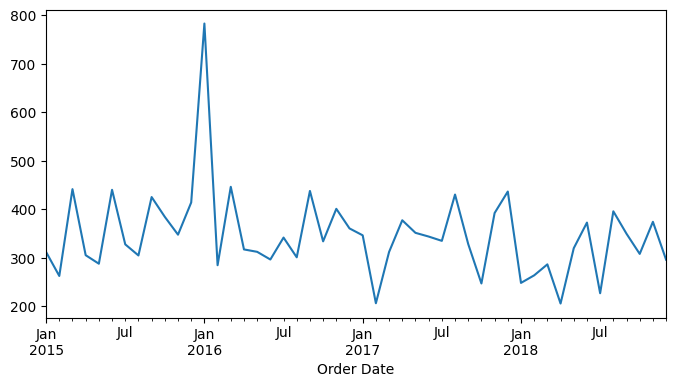

In [20]:
y.plot(figsize=(8, 4))
plt.show()

- Good Reference: https://ehfgk78.github.io/2018/01/21/DataScience07TimeSeriesData01/

## ARIMA 예측
- 시계열 데이터 기반 분석 기법
- 과거 지식이나 경험을 바탕으로 한 행동에 따라 경제가 움직이고 있음을 기초로 한다.
- ARIMA 모델의 각 매개변수
  - AR (AutoRegressive, $p$): 자기회귀 (과거 관측값의 선형 결합)
  - I (Integrated, $d$): 차분 차수 (정상성을 만들기 위해 차분한 횟수)
  - MA (Moving Average, $q$): 이동평균 (과거 예측 오차의 선형 결합)
- 시계열 정보 -> 규칙성을 가지는 패턴과 불규칙한 패턴의 결합
  - 규칙성을 만드는 패턴:
    - 자기 상관성(Autocorrelation): 이전의 결과와 이후의 결과 사이에서 발생
    - 이동 평균(Moving Average): 이전에 생긴 불규칙한 사건이 이후의 결과에 편향성을 초래하는 현상
  - 불규칙한 패턴
     - White Noise

- AR(p) model: 예측하고자 하는 특정 변수의 과거 관측값의 선형결합으로 미래값을 예측
  - y_t: t 시점의 관측값, c: 상수, θ: 가중치, $\epsilon_{t}$: 오차항

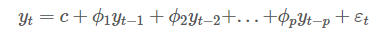

- MA(q) model: 예측오차를 이용하여 미래를 예측하는 모형

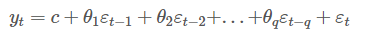

- ARMA = AR + MA
- to make non-stationary data into staionary -> use differencing (차분)
  - y' = y_t - y_(t-1) = Δy_t (1차 차분)
  - y' = y_t - y_(t-2) = Δ(2)y_t (2차 차분)
  - ...
  - 시계열은 추세가 있으면 예측이 어렵다.
  - 예를 들어,
    100, 105, 110, 115, 120 은 계속 증가한다.
  - 이를, 5, 5, 5, 5 처럼 차분하면 평균이 일정한 데이터가 된다.


- ARIMA(p,d,q) model: d 차 차분한 데이터의 AR(p) 와 MA(q) 모형을 합친 모형
  - y': d 차 차분 시계열, d:차분 회수

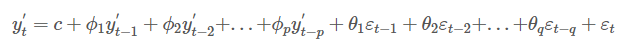

- d value: 시계열의 차이를 가져와 각 값에서 이전 값을 빼서 데이터를 더 고정시킴(statioanry)
- s: 계절적 요인 (seasonal)

## seasonal_decompose():
- 예측 모델이 아니고, 시계열 분석에서 모델링 이전의 탐색적 데이터 분석(EDA) 단계에 해당한다.
- 시계열을 4개의 성분으로 분해한 결과를 보여준다.
  - Observed = Trend + Seasonal + Residual
- SARIMA를 적용하기 전에 다음을 확인하기 위해 사용한다.
  - Trend가 있는가?
    - 있다면 d=1 차분이 필요할 가능성이 크다.
  - 계절성이 있는가?
    - 있다면, m=12 또는 m=7 같은 계절 주기를 사용.
  - 계절성이 얼마나 강한가?
    - 강하면, P,D,Q 를 포함하는 SARIMA가 적합하다.
  - Residual이 랜덤인가?
    - 랜덤이면, 모델이 설명해야 할 대부분의 구조를
Trend와 Seasonal이 설명하고 있다는 의미이다.


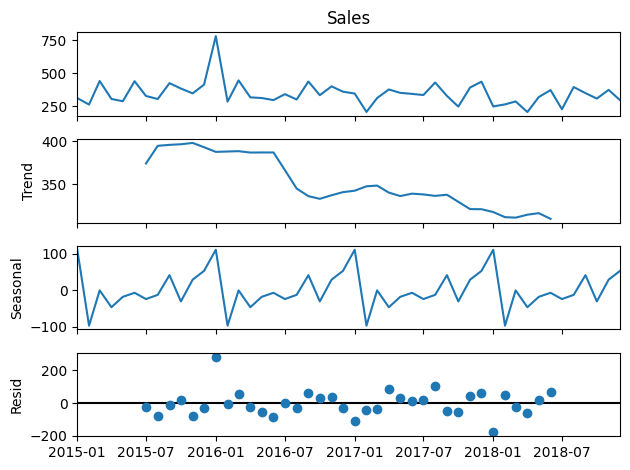

In [21]:
from statsmodels.tsa.seasonal import seasonal_decompose

# period:계절성 주기(Seasonality Cycle) - 월별 데이터 (12), 일별 데이터(7), 시간별 데이터 (24), 분기별 데이터(4)
decomposition = seasonal_decompose(y, model='additive', period=12)
fig = decomposition.plot()
plt.show()

- 분석:
  - 추세 존재: yes -> SARIMA에서 d = 1 사용
  - 계절성 존재: 매우 강함 -> m = ? 을 꼭 사용
  - 계절성 진폭: 거의 일정 -> additive 가 적절
  - 잔차: 거의 랜덤 -> Trend와 Seasonal이 상당 부분 설명하고 있다.
  - Seasonal 그래프를 약 12개의 값이 반복 (period=12)

- 분석:
  - Trend: 시간이 지날수록 평균 수준이 조금씩 감소하므로 장기 추세가 존재.
  - Seasonal: 거의 동일한 패턴이 일정한 진폭으로 반복되므로 강한 계절성이 있다. 따라서 SARIMA와 같은 계절 모델을 사용하는 것이 적절하다.
  - Residual: 대부분 0을 중심으로 무작위로 분포하므로, 추세와 계절성만으로도 데이터의 주요 구조가 상당 부분 설명되고 있다. 다만 몇 개의 큰 잔차는 이상치나 특별한 이벤트를 나타낼 가능성이 있으므로 별도로 확인해 볼 가치가 있다.
- SARIMA 에 적용:
  - SARIMA(p,1,q)(P,1,Q,12)
  - 일반 차분(d=1): 감소 추세 제거
  - 계절 차분(D=1): 매년 반복되는 계절성 제거
  - 계절 주기(m=12): 월별 데이터 가정

## SARIMA: modeling and forecasting

- 여러 경우의 p, d, q 조합을 만들고 어떤 모델이 가장 실제 데이터를 잘 설명하는지 찾아야 함.
- 예를 들어 SARIMA(2,1,1)(1,1,1,12)의 해석:
  - AR(2): 직전 2개의 관측값을 사용
  - I(1): 1차 차분으로 추세 제거
  - MA(1): 직전 1개의 예측 오차를 반영
  - Seasonal AR(1): 12개월 전(작년 같은 달)의 값을 반영
  - Seasonal Difference(1): 작년 같은 달과의 차분 수행
  - Seasonal MA(1): 12개월 전의 예측 오차를 반영
- 즉, "최근의 변화"와 "작년 같은 시기의 패턴"을 동시에 고려하여 다음 값을 예측하는 모델이라고 이해하면 된다. 예를 들면,
  - ARIMAX(
    order=(1,1,1),
    seasonal_order=(1,1,1,12)) 는

  - 최근 데이터와 작년 같은 달의 데이터를 모두 이용하여 예측한다는 의미.

In [22]:
p = d = q = range(0, 2)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]

In [23]:
print(pdq)
print(seasonal_pdq)

[(0, 0, 0), (0, 0, 1), (0, 1, 0), (0, 1, 1), (1, 0, 0), (1, 0, 1), (1, 1, 0), (1, 1, 1)]
[(0, 0, 0, 12), (0, 0, 1, 12), (0, 1, 0, 12), (0, 1, 1, 12), (1, 0, 0, 12), (1, 0, 1, 12), (1, 1, 0, 12), (1, 1, 1, 12)]


- 모델 요약 결과 해석 (Model Summary)
  - 모형 적합도 지표 (AIC, BIC)
    - log-Likelihood (로그 우도): 모델이 데이터를 얼마나 잘 설명하는지 나타내며, 높을수록 좋다.AIC (Akaike Information Criterion) & BIC (Bayesian Information Criterion): 모델의 예측 능력과 복잡성(파라미터 개수)을 동시에 고려한 지표이다.
    - 해석 방법: 여러 사후 후보 모델($SARIMA(p,d,q)(P,D,Q)_s$)을 비교할 때, AIC와 BIC 값이 가장 낮은 모델을 최적의 모델로 선택한다.
  - 계수(Coefficients)의 통계적 유의성
    - 각 파라미터(ar, ma, seasonal ar, seasonal ma 등)의 $P>|z|$ (p-value) 값을 확인해야 한다.
    - 해석 방법: 유의수준 0.05를 기준으로, p-value가 0.05보다 작아야 해당 파라미터가 시계열을 설명하는 데 통계적으로 유의미하다고 판단한다. 만약 p-value가 너무 크다면 해당 성분을 모델에서 제외하거나 차수를 낮추는 것을 고려해야 한다.

- 잔차 진단 (Residual Diagnostics)
  - 선택된 모델이 데이터의 패턴을 충분히 학습했다면, 남은 오차인 잔차(Residual)는 아무런 패턴이 없는 백색 잡음(White Noise) 상태여야 한다. model.plot_diagnostics() 함수를 사용하면 네 가지 그래프로 이를 한눈에 시각화할 수 있다.

- 예측 성능 평가 (Forecasting & Evaluation)
  - 시각적 확인: 학습 데이터 끝단 이후의 실제 값(Actual)과 모델이 예측한 값(Forecast)을 한 그래프에 그리고, 모델이 제공하는 신뢰구간(Confidence Interval, 보통 95%) 안에 실제 데이터가 안정적으로 들어오는지 확인한다.
  - 정량적 평가지표 활용: 오차의 크기를 계산하여 모델의 최종 성능을 판단 (MAE, RMSE)

- AIC(Akaike Information Criterion)의 수학적 정의
  - $$AIC = 2k - 2\ln(L)$$
  - $k$: 모델 추정에 사용된 자유 파라미터(Free Parameter)의 개수 ($\text{ARIMA}(p, d, q)$ 모델에서는 일반적으로 $k = p + q + 1$ (절편 포함 시 $+1$, 잔차 분산 포함 여부에 따라 달라짐)
  - $L$: 최우추정법(Maximum Likelihood Estimation, MLE)으로 구한 최대 우도(Maximum Likelihood)

### Train

In [24]:
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX

- Many time series exhibit both non-seasonal and seasonal patterns.
  - (p,d,q): non-seasonal components
  - (P,D,Q,S): seasonal components (similar to (p,d,q) but applies to the seasonal component of the model.

- grid search

In [25]:
best_aic = np.inf
best_pdq = None
best_seasonal_pdq = None
tmp_model = None
best_model = None

p = d = q = range(0, 2)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = SARIMAX(y,
                          order=param,
                          seasonal_order=param_seasonal,
                          enforce_stationarity=False,   # encforce stationarity for AR
                          enforce_invertibility=False)  # encforce stationarity for MA
            results = mod.fit()
            print('ARIMA{}x{}12 - AIC:{}'.format(param, param_seasonal, results.aic))

            if results.aic < best_aic:
                best_aic = results.aic
                best_pdq = param
                best_seasonal_pdq = param_seasonal
                best_model = mod

        except:
            continue

print("***")
print("Best SARIMAX{}x{}12 model - AIC:{}".format(best_pdq, best_seasonal_pdq, best_aic))

ARIMA(0, 0, 0)x(0, 0, 0, 12)12 - AIC:688.3112416991725
ARIMA(0, 0, 0)x(0, 0, 1, 12)12 - AIC:1536.8757284930073
ARIMA(0, 0, 0)x(0, 1, 0, 12)12 - AIC:426.2046489859171
ARIMA(0, 0, 0)x(0, 1, 1, 12)12 - AIC:272.0919847628291
ARIMA(0, 0, 0)x(1, 0, 0, 12)12 - AIC:452.8238602501692
ARIMA(0, 0, 0)x(1, 0, 1, 12)12 - AIC:1397.9723490853378
ARIMA(0, 0, 0)x(1, 1, 0, 12)12 - AIC:295.44645647223496
ARIMA(0, 0, 0)x(1, 1, 1, 12)12 - AIC:274.0919845632798
ARIMA(0, 0, 1)x(0, 0, 0, 12)12 - AIC:641.1240680666134
ARIMA(0, 0, 1)x(0, 0, 1, 12)12 - AIC:2687.9682996957517
ARIMA(0, 0, 1)x(0, 1, 0, 12)12 - AIC:416.5496453364606
ARIMA(0, 0, 1)x(0, 1, 1, 12)12 - AIC:262.5230517047695
ARIMA(0, 0, 1)x(1, 0, 0, 12)12 - AIC:455.15635077573427


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimat

ARIMA(0, 0, 1)x(1, 0, 1, 12)12 - AIC:2517.3598444294885
ARIMA(0, 0, 1)x(1, 1, 0, 12)12 - AIC:297.44640662502127
ARIMA(0, 0, 1)x(1, 1, 1, 12)12 - AIC:264.523001312815
ARIMA(0, 1, 0)x(0, 0, 0, 12)12 - AIC:580.638926970597
ARIMA(0, 1, 0)x(0, 0, 1, 12)12 - AIC:1456.8188418111358
ARIMA(0, 1, 0)x(0, 1, 0, 12)12 - AIC:433.3552136704604
ARIMA(0, 1, 0)x(0, 1, 1, 12)12 - AIC:274.10692957471474
ARIMA(0, 1, 0)x(1, 0, 0, 12)12 - AIC:437.46040107889746
ARIMA(0, 1, 0)x(1, 0, 1, 12)12 - AIC:1223.5476726873633
ARIMA(0, 1, 0)x(1, 1, 0, 12)12 - AIC:294.1158452476943
ARIMA(0, 1, 0)x(1, 1, 1, 12)12 - AIC:276.1053314166442
ARIMA(0, 1, 1)x(0, 0, 0, 12)12 - AIC:538.8964721447164


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimat

ARIMA(0, 1, 1)x(0, 0, 1, 12)12 - AIC:2463.8162758459507
ARIMA(0, 1, 1)x(0, 1, 0, 12)12 - AIC:412.87269899052046
ARIMA(0, 1, 1)x(0, 1, 1, 12)12 - AIC:251.2470775508364
ARIMA(0, 1, 1)x(1, 0, 0, 12)12 - AIC:419.18397927249225
ARIMA(0, 1, 1)x(1, 0, 1, 12)12 - AIC:2111.1993591110654
ARIMA(0, 1, 1)x(1, 1, 0, 12)12 - AIC:273.4032454636057
ARIMA(0, 1, 1)x(1, 1, 1, 12)12 - AIC:253.21964764619594
ARIMA(1, 0, 0)x(0, 0, 0, 12)12 - AIC:592.7661498749849


...

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimat

ARIMA(1, 0, 1)x(0, 1, 1, 12)12 - AIC:263.82167771134436
ARIMA(1, 0, 1)x(1, 0, 0, 12)12 - AIC:422.4003583323525
ARIMA(1, 0, 1)x(1, 0, 1, 12)12 - AIC:1887.652828841562
ARIMA(1, 0, 1)x(1, 1, 0, 12)12 - AIC:275.47757405307715
ARIMA(1, 0, 1)x(1, 1, 1, 12)12 - AIC:265.8212105873432
ARIMA(1, 1, 0)x(0, 0, 0, 12)12 - AIC:566.5211872508684
ARIMA(1, 1, 0)x(0, 0, 1, 12)12 - AIC:1287.9393855565868
ARIMA(1, 1, 0)x(0, 1, 0, 12)12 - AIC:430.33057708179365
ARIMA(1, 1, 0)x(0, 1, 1, 12)12 - AIC:273.4321378325952
ARIMA(1, 1, 0)x(1, 0, 0, 12)12 - AIC:397.36689816515843


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for va

ARIMA(1, 1, 0)x(1, 0, 1, 12)12 - AIC:1383.727429040953
ARIMA(1, 1, 0)x(1, 1, 0, 12)12 - AIC:273.4415398792927
ARIMA(1, 1, 0)x(1, 1, 1, 12)12 - AIC:275.41278577499264
ARIMA(1, 1, 1)x(0, 0, 0, 12)12 - AIC:540.6257368397356
ARIMA(1, 1, 1)x(0, 0, 1, 12)12 - AIC:2579.218367464277
ARIMA(1, 1, 1)x(0, 1, 0, 12)12 - AIC:414.7726173041488
ARIMA(1, 1, 1)x(0, 1, 1, 12)12 - AIC:252.6613432747477
ARIMA(1, 1, 1)x(1, 0, 0, 12)12 - AIC:391.8303255543242
ARIMA(1, 1, 1)x(1, 0, 1, 12)12 - AIC:473.2517221389627
ARIMA(1, 1, 1)x(1, 1, 0, 12)12 - AIC:263.9371084381279
ARIMA(1, 1, 1)x(1, 1, 1, 12)12 - AIC:254.6420713204588
***
Best SARIMAX(0, 1, 1)x(0, 1, 1, 12)12 model - AIC:251.2470775508364


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


- SARIMAX(0, 1, 1)x(0, 1, 1, 12) yields the lowest AIC value of 251

In [26]:
# define the model and fit it to the data

mod = SARIMAX(y,
              order=(0, 1, 1),
              seasonal_order=(0, 1, 1, 12))
results = mod.fit()
print(results.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9982     13.522     -0.074      0.941     -27.502      25.505
ma.S.L12      -0.9855     13.786     -0.071      0.943     -28.005      26.034
sigma2      7620.1335   1.68e+05      0.045      0.964   -3.22e+05    3.37e+05


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [ ]:
# print(results.summary())

- ar.L1: AR coeffiient at lag 1
- ma.L1: the coefficient of the MA at lag 1
- ma.S.L12: seasonal autoregressive coefficient at lag 12
- sigma2: the estimated variance of the error term (also known as the white noise term) - difference between the observed values and the predicted values
- A smaller value of sigma2 indicates a better fit with less unexplained variance. In this case, 1.252e+04 (a large number) suggests that there is still a significant amount of unexplained variability in your model.

- null hypothesis (H0): there is no significant relationship or effect (specific parameter has no effect)
  - low p-value: reject H0 (he corresponding parameter is likely significant and has a non-zero effect on the response variable.) (good fit)
  - high p-value: weaker or non-significant relationship between the predictor variable and the response variable (i.e. bad fit)

### 동작을 확인하기 위한 모델 검사(model diagnostics)
 아래 결과를 보면 오차 (residuals)가 거의 정규분포를 따른다 - positive sign (긍정적)



#### results.plot_diagnostics()
- SARIMA나 ARIMA 같은 시계열 모델을 학습한 후, "모델이 데이터의 패턴을 빠짐없이 잘 학습했는가?"(즉, 잔차가 백색 잡음인가)를 시각적으로 검증하기 위해 제공되는 매우 강력한 시각화 도구.
  - Standardized residual (표준화된 잔차 플롯):
    - 시간에 따른 오차(잔차)의 흐름을 보여준다.
    - 이상적인 형태: 변동 폭이 시간의 흐름에 따라 일정하고, 평균 0을 중심으로 위아래로 무작위로 무질서하게 흩어져 있는 형태여야 한다.
    - 분석 방법: 만약 특정 시점에 변동성이 갑자기 커지거나(이차 분산성), 전체적으로 상승/하강하는 트렌드가 보인다면 모델이 데이터의 중요한 규칙성이나 변동성을 미처 다 잡아내지 못했다는 뜻이다.
  - Histogram plus estimated density (히스토그램 및 밀도 추정)
    - 오차들의 분포가 정규분포를 따르는지 확인하는 그래프
    - 이상적인 형태: 실제 잔차의 분포인 초록색 선(KDE)이 이론적인 표준정규분포인 주황색 선($N(0,1)$)과 예쁘게 겹치며 종 모양을 이루어야 한다.
    - 분석 방법: 두 선이 심하게 어긋나 있거나 한쪽으로 치우쳐 있다면, 오차가 정규성을 만족하지 못한다는 의미이다. 이는 모델의 예측 신뢰구간이 다소 부정확할 수 있음을 암시한다.
  - Normal Q-Q (정규 Q-Q 플롯)
    - 잔차의 분위수(Quantiles)와 정규분포의 분위수를 일대일로 매핑하여 정규성을 더 엄격하게 시각화한 것.
    - 이상적인 형태: 그래프에 그려진 파란색 점들이 붉은색 대각선 기준 위에 완벽하게 일직선으로 정렬되어야 한다.
    - 분석 방법: 점들이 직선을 잘 따르다가 양쪽 끝단에서 심하게 휘어지거나 벗어난다면, 데이터에 평균적인 범위를 크게 벗어나는 이상치(Outlier)나 두터운 꼬리(Heavy tail)가 존재함을 의미한다.
  - Correlogram (자기상관 플롯, ACF)
    - 잔차들끼리 시간의 시차(Lag)에 따라 서로 연관성이 있는지(자기상관)를 나타낸다.
    - 이상적인 형태: 시차 0(자기 자신과의 상관관계이므로 항상 1)을 제외한 모든 막대들이 흐린 파란색 음영(신뢰구간) 안쪽에 갇혀 있어야 한다.
    - 분석 방법: 만약 음영 영역 위로 툭 튀어나온 막대가 있다면(특히 특정 계절성 주기에 해당하는 시차에서), 모델이 시계열의 선행 패턴을 다 학습하지 못하고 오차에 그 패턴을 남겨두었다는 명백한 증거이다. 차수($p, q, P, Q$)를 더 높여야 함을 뜻한다.
- 이 4개 그래프의 궁극적인 목적은 하나이다. "패턴은 모델이 다 가져갔으니, 남은 찌꺼기(오차)에는 아무런 규칙도 없어야 한다"는 점을 증명하는 것이다.
- 4개 그래프 모두가 이상적인 기준을 만족한다면, 해당 SARIMA 모델은 데이터의 특성을 아주 잘 추출해 낸 신뢰할 수 있는 모델이라고 결론지을 수 있다.



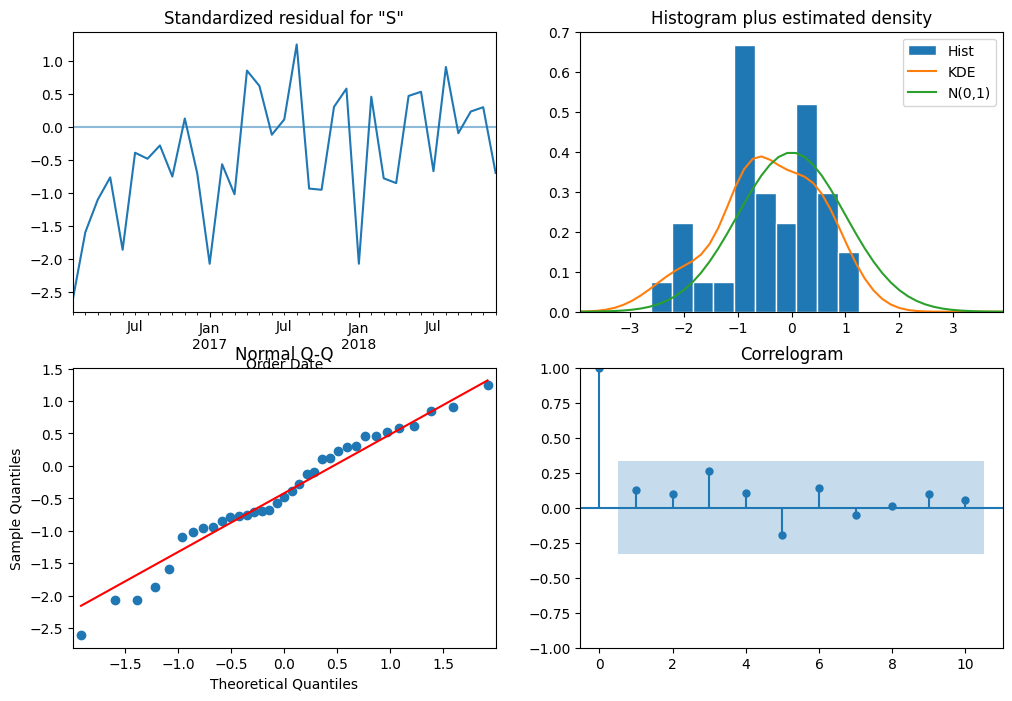

In [27]:
results.plot_diagnostics(figsize=(12, 8))
plt.show()

### Prediction (예측수행)


- get_prediction( , dynamic=False)
    - 모델로부터 특정 기간에 대한 예측 결과 객체를 가져오는 함수이다.
    - 단순한 예측 숫자 배열이 아니라, 예측값의 평균(predicted_mean), 분산, 신뢰구간 등 다양한 통계적 정보를 품고 있는 PredictionResults 객체를 반환한다.
    - dynamic=False (기본값)의 의미: 예측할 때 바로 직전 시점의 '실제 데이터(Actual)'를 기반으로 한 단계 앞을 예측($t-1$ 시점의 실제 값으로 $t$ 시점을 예측)한다. 모델이 과거 데이터를 얼마나 잘 따라가는지(Fit) 검증할 때 사용한다. (만약 dynamic=True라면?: 지정한 시점부터는 실제 데이터를 쓰지 않고, 모델이 스스로 예측한 값을 다시 다음 예측의 입력으로 사용하는 '재귀적 예측'을 수행한다. 미래 구간(Out-of-sample)을 예측할 때는 자동으로 이 dynamic 방식으로 작동한다.)
- conf_int(alpha=0.05)
  - 예측값의 신뢰구간(Confidence Interval)을 계산해 준다.
  - 분석적 해석: 모델은 "내가 예측한 점수(평균값)는 $X$지만, 실제 데이터는 $95%$의 확률로 [하한값, 상한값] 사이에 존재할 것"이라고 선언하는 것이다. 예측 기간이 미래로 멀어질수록 불확실성이 커지기 때문에 상한값과 하한값의 간격(신뢰구간의 폭)은 점점 넓어지는 파이프 형태를 그리게 된다.
- fill_between(x, y1, y2, ...)
  - 두 선 사이의 영역을 색상으로 채워주는 역할을 한다. 시계열 분석에서는 주로 위에서 구한 신뢰구간 영역을 음영 처리할 때 필수적으로 사용된다.

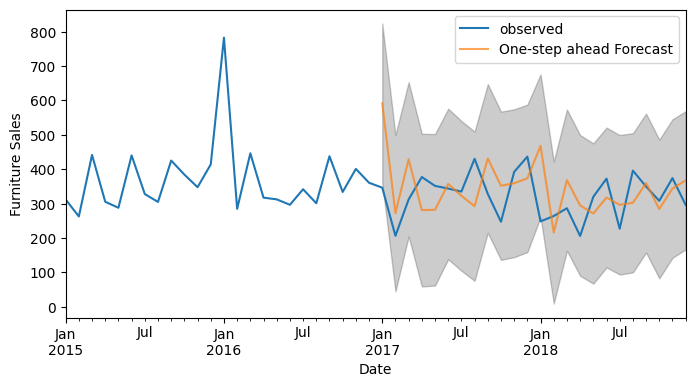

In [28]:
pred = results.get_prediction(start=pd.to_datetime('2017-01-01'), dynamic=False) # dynamic=False: 이전 시점의 실제 관측 데이터를 예측에 사용
pred_ci = pred.conf_int()
ax = y['2014':].plot(label='observed')

pred.predicted_mean.plot(ax=ax,
                         label='One-step ahead Forecast',
                         alpha=.7,
                         figsize=(8, 4))
ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1], color='k', alpha=.2)
ax.set_xlabel('Date')
ax.set_ylabel('Furniture Sales')
plt.legend()
plt.show()

In [29]:
y_forecasted = pred.predicted_mean
y_truth = y['2017-01-01':]
mse = ((y_forecasted - y_truth) ** 2).mean()
print('MSE is {}'.format(round(mse, 2)))
print('RMSE is {}'.format(round(np.sqrt(mse), 2)))

MSE is 9531.22
RMSE is 97.63


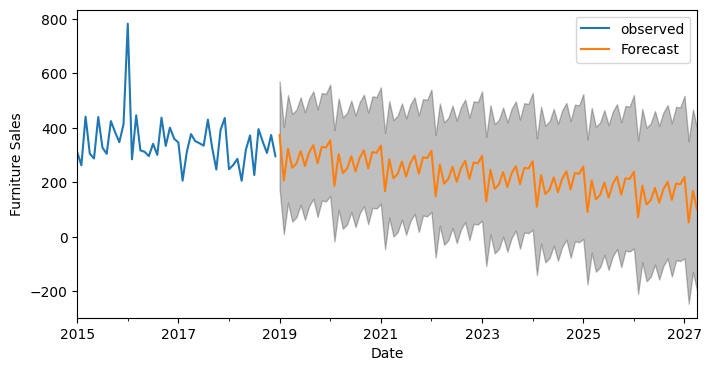

In [30]:
# confidence interval은 점차 증가한다.
pred_uc = results.get_forecast(steps=100)
pred_ci = pred_uc.conf_int()

ax = y.plot(label='observed', figsize=(10, 5))
pred_uc.predicted_mean.plot(ax=ax, label='Forecast', figsize=(8, 4))
ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1], color='k', alpha=.25)
ax.set_xlabel('Date')
ax.set_ylabel('Furniture Sales')
plt.legend()
plt.show()


- 다른 항목의 변화와 비교 가구 <-> 사무용품

In [31]:
furniture = df.loc[df['Category'] == 'Furniture']
office = df.loc[df['Category'] == 'Office Supplies']
furniture.shape, office.shape

((2121, 21), (6026, 21))

In [32]:
office[:3]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,0.0,6.8714
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,2,0.2,2.5164
6,7,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032.0,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.280,4,0.0,1.9656


In [33]:
furniture[:3]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310


In [34]:
furniture = furniture[['Order Date', 'Sales']]
office = office[['Order Date', 'Sales']]
furniture = furniture.sort_values('Order Date')
office = office.sort_values('Order Date')

In [35]:
furniture.groupby('Order Date')['Sales'].sum()

,Sales
Order Date,
2015-01-06,2573.8200
2015-01-07,76.7280
2015-01-10,51.9400
2015-01-11,9.9400
2015-01-13,879.9390
...,...
2018-12-24,1393.4940
2018-12-25,832.4540
2018-12-28,551.2568


In [36]:
furniture.groupby('Order Date')['Sales'].sum().reset_index()

,Order Date,Sales
0,2015-01-06,2573.8200
1,2015-01-07,76.7280
2,2015-01-10,51.9400
3,2015-01-11,9.9400
4,2015-01-13,879.9390
...,...,...
884,2018-12-24,1393.4940
885,2018-12-25,832.4540
886,2018-12-28,551.2568
887,2018-12-29,2330.7180


In [37]:
furniture = furniture.groupby('Order Date')['Sales'].sum().reset_index()
furniture = furniture.set_index('Order Date')
y_furniture = furniture['Sales'].resample('MS').mean()

office = office.groupby('Order Date')['Sales'].sum().reset_index()
office = office.set_index('Order Date')
y_office = office['Sales'].resample('MS').mean()

furniture = pd.DataFrame({'Order Date':y_furniture.index, 'Sales':y_furniture.values})
office = pd.DataFrame({'Order Date': y_office.index, 'Sales': y_office.values})
store = furniture.merge(office, how='inner', on='Order Date')
store.rename(columns={'Sales_x': 'furniture_sales', 'Sales_y': 'office_sales'}, inplace=True)
store.head()


,Order Date,furniture_sales,office_sales
0,2015-01-01,480.194231,285.357647
1,2015-02-01,367.931600,63.042588
2,2015-03-01,857.291529,391.176318
3,2015-04-01,567.488357,464.794750
4,2015-05-01,432.049188,324.346545


In [38]:
store.shape

(48, 3)

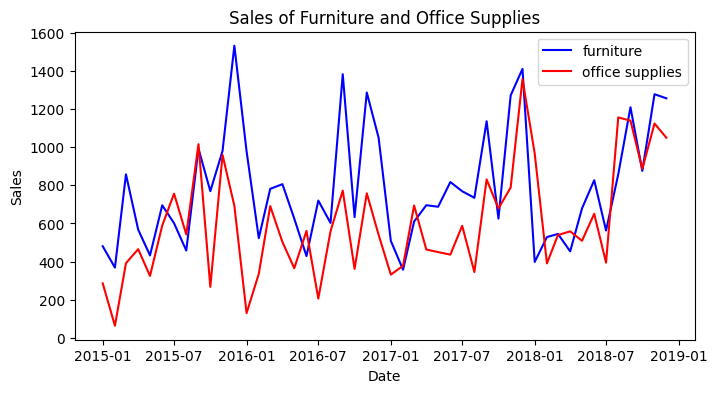

In [39]:
plt.figure(figsize=(8, 4))
plt.plot(store['Order Date'], store['furniture_sales'], 'b-', label = 'furniture')
plt.plot(store['Order Date'], store['office_sales'], 'r-', label = 'office supplies')
plt.xlabel('Date'); plt.ylabel('Sales');
plt.title('Sales of Furniture and Office Supplies')
plt.legend();


- 유사한 계절적 특성을 갖는다.
- 사무용품 매출이 가구 매출을 앞지르는 시점을 찾아보겠다.

In [40]:
np.where(store['office_sales'] > store['furniture_sales'])

(array([ 6,  7,  8, 17, 25, 26, 33, 36, 39, 43, 45]),)

In [41]:
where = np.where(store['office_sales'] > store['furniture_sales'])
first_date = store.iloc[np.min(where)]['Order Date']
print("사무용품 매출이 가구매출을 앞지르는 시점: {}.".format(first_date.date()))

사무용품 매출이 가구매출을 앞지르는 시점: 2015-07-01.


# Prophet
- Meta(구 Facebook)에서 개발한 오픈소스 시계열 예측 라이브러리이다. 학계의 복잡한 통계적 지식이 부족한 일반 비즈니스 분석가들도 쉽게 강력하고 직관적인 예측 모델을 만들 수 있도록 설계된 툴이다.
- 현업 비즈니스 데이터(매출, 웹 트래픽, 콜센터 통화량 등)를 다룰 때 가성비와 편의성이 극도로 뛰어난 최고의 선택지 중 하나이다. 하지만 금융 데이터나 정밀한 물리 센서 데이터에는 잘 맞지 않는다.
- Prophet의 내부 메커니즘 (작동 원리)
  - ARIMA 같은 전통적인 수리 통계 모델이나 RNN 같은 딥러닝과 달리, 시계열 데이터를 수학적인 가법 모델(Additive Model)로 분해하여 접근한다. 쉽게 말해, 전체 데이터를 아래의 세 가지 성분의 합으로 표현한다.
  - $$y(t) = g(t) + s(t) + h(t) + \epsilon_t$$
    - $g(t)$ (Trend, 추세): 비주기적인 변화(장기적인 상승 또는 하강)를 잡는다. 특히 시장 상황이 바뀌는 지점(Chgpoints, 변곡점)을 자동으로 감지하는 능력이 탁월하다.
    - $s(t)$ (Seasonality, 계절성): 주기적인 변화를 잡는다. 기본적으로 일간, 주간, 연간 계절성을 자동으로 반영하며, 푸리에 급수(Fourier Series)를 사용하여 복잡한 주기성도 유연하게 모델링한다.
    - $h(t)$ (Holidays, 휴일 효과): 비즈니스 예측에서 가장 중요한 추석, 설날, 블랙 프라이데이 같은 불규칙한 이벤트의 충격을 반영한다.
    - $\epsilon_t$: 모델이 설명하지 못하는 나머지 무작위 오차이다

In [ ]:
from prophet import Prophet

In [ ]:
furniture = furniture.rename(columns={'Order Date': 'ds', 'Sales': 'y'}) # column 이름을 맞춰야 함
furniture_model = Prophet(interval_width=0.95)  # uncertainty interval (confidence interval)
furniture_model.fit(furniture)

office = office.rename(columns={'Order Date': 'ds', 'Sales': 'y'})
office_model = Prophet(interval_width=0.95)
office_model.fit(office)

# 1. create a new DataFrame that contains future timestamps (dates), and
# 2. make predictions for the future dates generated using make_future_dataframe()

furniture_forecast = furniture_model.make_future_dataframe(periods=36, freq='MS')
furniture_forecast = furniture_model.predict(furniture_forecast)

office_forecast = office_model.make_future_dataframe(periods=36, freq='MS')
office_forecast = office_model.predict(office_forecast)


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


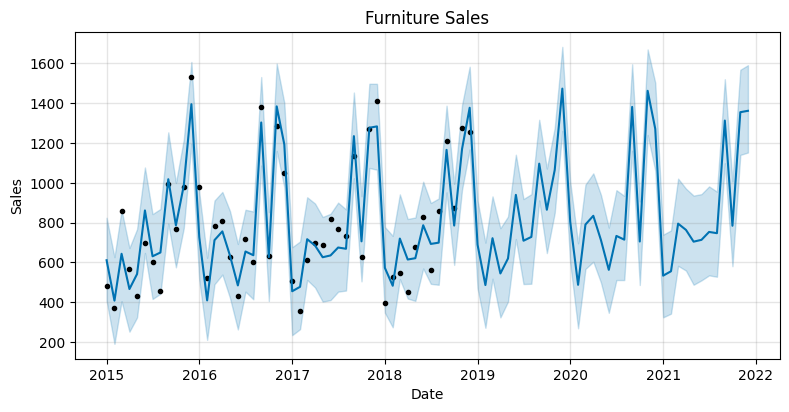

In [ ]:
# plt.figure(figsize=(8, 4))
fig = furniture_model.plot(furniture_forecast, xlabel = 'Date', ylabel = 'Sales',
                           figsize=(8,4))
plt.title('Furniture Sales');

<Figure size 1200x400 with 0 Axes>

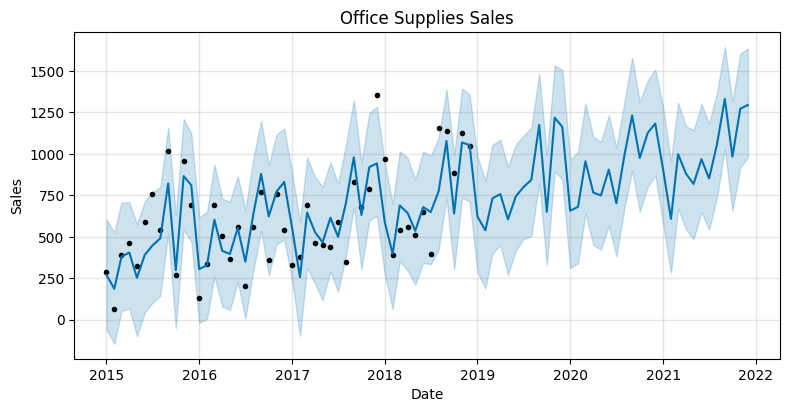

In [ ]:
plt.figure(figsize=(12, 4))
office_model.plot(office_forecast, xlabel = 'Date', ylabel = 'Sales',
                  figsize=(8,4))
plt.title('Office Supplies Sales');

### 두개의 변수를 동시에 보기

In [ ]:
furniture_forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-01-01,737.442886,407.407968,824.169166,737.442886,737.442886,-126.834384,-126.834384,-126.834384,-126.834384,-126.834384,-126.834384,0.0,0.0,0.0,610.608502
1,2015-02-01,739.106346,189.984069,625.920459,739.106346,739.106346,-331.842972,-331.842972,-331.842972,-331.842972,-331.842972,-331.842972,0.0,0.0,0.0,407.263374
2,2015-03-01,740.608826,404.863509,863.795645,740.608826,740.608826,-97.493823,-97.493823,-97.493823,-97.493823,-97.493823,-97.493823,0.0,0.0,0.0,643.115002
3,2015-04-01,742.272285,251.320294,672.124509,742.272285,742.272285,-276.534317,-276.534317,-276.534317,-276.534317,-276.534317,-276.534317,0.0,0.0,0.0,465.737969
4,2015-05-01,743.882085,322.716484,766.962811,743.882085,743.882085,-202.808133,-202.808133,-202.808133,-202.808133,-202.808133,-202.808133,0.0,0.0,0.0,541.073952


In [ ]:
furniture_names = ['furniture_%s' % column for column in furniture_forecast.columns]
merge_furniture_forecast = furniture_forecast.copy()
merge_furniture_forecast.columns = furniture_names
merge_furniture_forecast.head(3)

,furniture_ds,furniture_trend,furniture_yhat_lower,furniture_yhat_upper,furniture_trend_lower,furniture_trend_upper,furniture_additive_terms,furniture_additive_terms_lower,furniture_additive_terms_upper,furniture_yearly,furniture_yearly_lower,furniture_yearly_upper,furniture_multiplicative_terms,furniture_multiplicative_terms_lower,furniture_multiplicative_terms_upper,furniture_yhat
0,2015-01-01,737.442886,407.407968,824.169166,737.442886,737.442886,-126.834384,-126.834384,-126.834384,-126.834384,-126.834384,-126.834384,0.0,0.0,0.0,610.608502
1,2015-02-01,739.106346,189.984069,625.920459,739.106346,739.106346,-331.842972,-331.842972,-331.842972,-331.842972,-331.842972,-331.842972,0.0,0.0,0.0,407.263374
2,2015-03-01,740.608826,404.863509,863.795645,740.608826,740.608826,-97.493823,-97.493823,-97.493823,-97.493823,-97.493823,-97.493823,0.0,0.0,0.0,643.115002


In [ ]:
office_names = ['office_%s' % column for column in office_forecast.columns]
merge_office_forecast = office_forecast.copy()
merge_office_forecast.columns = office_names
merge_office_forecast.head(3)

,office_ds,office_trend,office_yhat_lower,office_yhat_upper,office_trend_lower,office_trend_upper,office_additive_terms,office_additive_terms_lower,office_additive_terms_upper,office_yearly,office_yearly_lower,office_yearly_upper,office_multiplicative_terms,office_multiplicative_terms_lower,office_multiplicative_terms_upper,office_yhat
0,2015-01-01,456.625680,-60.744234,604.160449,456.625680,456.625680,-187.487800,-187.487800,-187.487800,-187.487800,-187.487800,-187.487800,0.0,0.0,0.0,269.137880
1,2015-02-01,464.105380,-146.811859,526.642407,464.105380,464.105380,-278.220843,-278.220843,-278.220843,-278.220843,-278.220843,-278.220843,0.0,0.0,0.0,185.884537
2,2015-03-01,470.861237,51.643272,706.441253,470.861237,470.861237,-92.104961,-92.104961,-92.104961,-92.104961,-92.104961,-92.104961,0.0,0.0,0.0,378.756276


In [ ]:
pd.merge(merge_furniture_forecast, merge_office_forecast, how = 'inner', left_on = 'furniture_ds', right_on = 'office_ds').T

,0,1,2,3,4,5,6,7,8,9,...,74,75,76,77,78,79,80,81,82,83
furniture_ds,2015-01-01 00:00:00,2015-02-01 00:00:00,2015-03-01 00:00:00,2015-04-01 00:00:00,2015-05-01 00:00:00,2015-06-01 00:00:00,2015-07-01 00:00:00,2015-08-01 00:00:00,2015-09-01 00:00:00,2015-10-01 00:00:00,...,2021-03-01 00:00:00,2021-04-01 00:00:00,2021-05-01 00:00:00,2021-06-01 00:00:00,2021-07-01 00:00:00,2021-08-01 00:00:00,2021-09-01 00:00:00,2021-10-01 00:00:00,2021-11-01 00:00:00,2021-12-01 00:00:00
furniture_trend,737.442886,739.106346,740.608826,742.272285,743.882085,745.545545,747.155344,748.818804,750.482264,752.092063,...,858.167778,859.830222,861.439039,863.101483,864.710299,866.372743,868.035187,869.644003,871.306447,872.915264
furniture_yhat_lower,407.407968,189.984069,404.863509,251.320294,322.716484,647.149617,415.65213,441.914896,794.860565,574.796355,...,582.482501,558.520473,487.307391,509.336647,534.541322,527.592338,1098.494687,580.365421,1140.104057,1152.363655
furniture_yhat_upper,824.169166,625.920459,863.795645,672.124509,766.962811,1076.92201,842.56725,868.300035,1253.793409,999.510489,...,1020.974409,970.664116,935.60711,943.074346,981.924274,955.462184,1520.888771,1007.231443,1568.412202,1591.440548
furniture_trend_lower,737.442886,739.106346,740.608826,742.272285,743.882085,745.545545,747.155344,748.818804,750.482264,752.092063,...,858.161159,859.823145,861.431706,863.093621,864.702133,866.364085,868.026363,869.634644,871.296541,872.904812
furniture_trend_upper,737.442886,739.106346,740.608826,742.272285,743.882085,745.545545,747.155344,748.818804,750.482264,752.092063,...,858.17458,859.8374,861.446454,863.109257,864.718592,866.381531,868.044355,869.653659,871.316526,872.925912
furniture_additive_terms,-126.834384,-331.842972,-97.493823,-276.534317,-202.808133,115.397483,-116.811658,-99.313732,267.443951,33.882418,...,-63.476342,-96.730956,-157.42989,-149.995567,-111.810315,-119.757383,444.982758,-85.643739,483.828239,489.112493
furniture_additive_terms_lower,-126.834384,-331.842972,-97.493823,-276.534317,-202.808133,115.397483,-116.811658,-99.313732,267.443951,33.882418,...,-63.476342,-96.730956,-157.42989,-149.995567,-111.810315,-119.757383,444.982758,-85.643739,483.828239,489.112493
furniture_additive_terms_upper,-126.834384,-331.842972,-97.493823,-276.534317,-202.808133,115.397483,-116.811658,-99.313732,267.443951,33.882418,...,-63.476342,-96.730956,-157.42989,-149.995567,-111.810315,-119.757383,444.982758,-85.643739,483.828239,489.112493
furniture_yearly,-126.834384,-331.842972,-97.493823,-276.534317,-202.808133,115.397483,-116.811658,-99.313732,267.443951,33.882418,...,-63.476342,-96.730956,-157.42989,-149.995567,-111.810315,-119.757383,444.982758,-85.643739,483.828239,489.112493


In [ ]:
forecast = pd.merge(merge_furniture_forecast, merge_office_forecast, how = 'inner', left_on = 'furniture_ds', right_on = 'office_ds')
forecast = forecast.rename(columns={'furniture_ds': 'Date'}).drop('office_ds', axis=1)
forecast.head()


,Date,furniture_trend,furniture_yhat_lower,furniture_yhat_upper,furniture_trend_lower,furniture_trend_upper,furniture_additive_terms,furniture_additive_terms_lower,furniture_additive_terms_upper,furniture_yearly,...,office_additive_terms,office_additive_terms_lower,office_additive_terms_upper,office_yearly,office_yearly_lower,office_yearly_upper,office_multiplicative_terms,office_multiplicative_terms_lower,office_multiplicative_terms_upper,office_yhat
0,2015-01-01,737.442886,407.407968,824.169166,737.442886,737.442886,-126.834384,-126.834384,-126.834384,-126.834384,...,-187.487800,-187.487800,-187.487800,-187.487800,-187.487800,-187.487800,0.0,0.0,0.0,269.137880
1,2015-02-01,739.106346,189.984069,625.920459,739.106346,739.106346,-331.842972,-331.842972,-331.842972,-331.842972,...,-278.220843,-278.220843,-278.220843,-278.220843,-278.220843,-278.220843,0.0,0.0,0.0,185.884537
2,2015-03-01,740.608826,404.863509,863.795645,740.608826,740.608826,-97.493823,-97.493823,-97.493823,-97.493823,...,-92.104961,-92.104961,-92.104961,-92.104961,-92.104961,-92.104961,0.0,0.0,0.0,378.756276
3,2015-04-01,742.272285,251.320294,672.124509,742.272285,742.272285,-276.534317,-276.534317,-276.534317,-276.534317,...,-73.556523,-73.556523,-73.556523,-73.556523,-73.556523,-73.556523,0.0,0.0,0.0,404.784414
4,2015-05-01,743.882085,322.716484,766.962811,743.882085,743.882085,-202.808133,-202.808133,-202.808133,-202.808133,...,-233.459028,-233.459028,-233.459028,-233.459028,-233.459028,-233.459028,0.0,0.0,0.0,252.120328


/tmp/ipykernel_1037/853800620.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(); plt.xlabel('Date'); plt.ylabel('Sales')
/tmp/ipykernel_1037/853800620.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(); plt.xlabel('Date'); plt.ylabel('Sales')


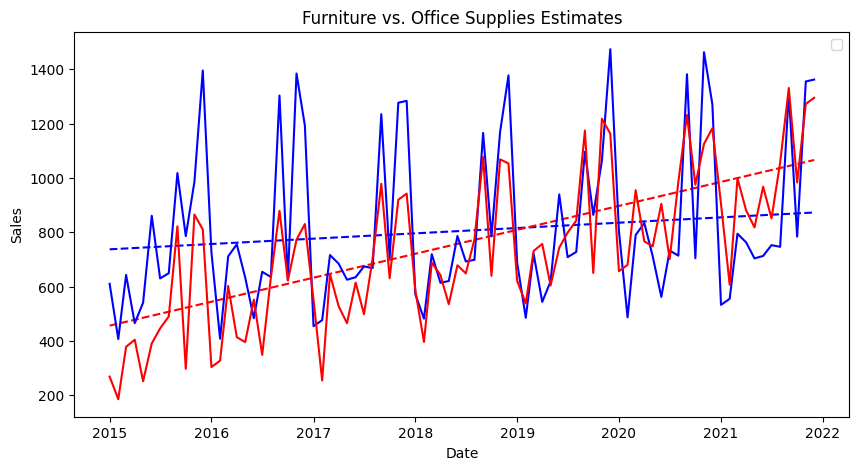

In [ ]:
# 트렌드 시각화
plt.figure(figsize=(10, 5))
plt.plot(forecast['Date'], forecast['furniture_trend'], 'b--')  # trend
plt.plot(forecast['Date'], forecast['office_trend'], 'r--')
plt.legend(); plt.xlabel('Date'); plt.ylabel('Sales')
plt.title('Furniture vs. Office Supplies Sales Trend');

# plt.figure(figsize=(10, 7))
plt.plot(forecast['Date'], forecast['furniture_yhat'], 'b-')    # estimates
plt.plot(forecast['Date'], forecast['office_yhat'], 'r-')
plt.legend(); plt.xlabel('Date'); plt.ylabel('Sales')
plt.title('Furniture vs. Office Supplies Estimates');


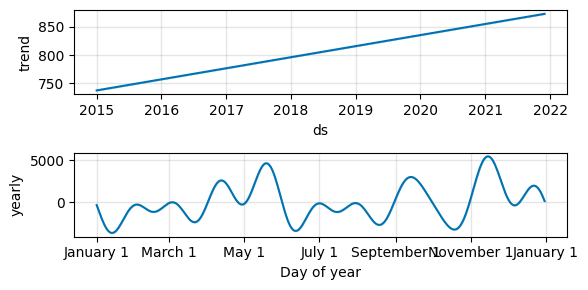

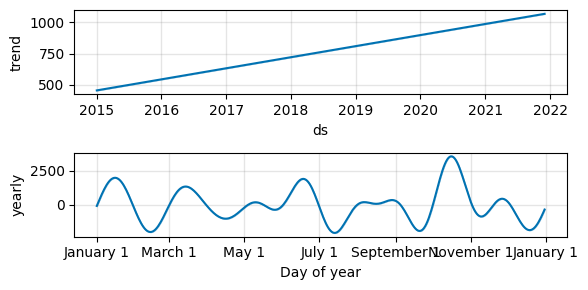

In [ ]:
furniture_model.plot_components(furniture_forecast, figsize=(6,3));
office_model.plot_components(office_forecast, figsize=(6,3));

- 지금까지 SARIMAX() 및 Prophet() 모델의 활용 예를 보여 주었음. 자세한 성능 분석이나 더 상세한 활용에 대해서는 관련 사이트에 있는 매뉴얼이나 예제 코드를 참고하기 바람.

# Exercise

In [ ]:
a = np.arange(10)
a

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [ ]:
np.where(a < 5, a+10, a*100)   # condition 을 기준으로 다른 계산

array([ 10,  11,  12,  13,  14, 500, 600, 700, 800, 900])

In [ ]:
np.where(a < 5)

(array([0, 1, 2, 3, 4]),)

In [ ]:
try:
    print(5/0)
except:    # 예외가 발생했을 때 실행됨
    print('예외가 발생했습니다.')
finally:
    print("try 문의 예외 상관없이 항상 실행...")

예외가 발생했습니다.
try 문의 예외 상관없이 항상 실행...


In [ ]:
# just for checking
list(itertools.product('ABC', repeat=2))

[('A', 'A'),
 ('A', 'B'),
 ('A', 'C'),
 ('B', 'A'),
 ('B', 'B'),
 ('B', 'C'),
 ('C', 'A'),
 ('C', 'B'),
 ('C', 'C')]

In [ ]:
list(itertools.product(range(2), range(2), range(2)))

[(0, 0, 0),
 (0, 0, 1),
 (0, 1, 0),
 (0, 1, 1),
 (1, 0, 0),
 (1, 0, 1),
 (1, 1, 0),
 (1, 1, 1)]

- df.groupby(): to group the data by the unique values in the 'car' column

In [ ]:
import pandas as pd

data = {
'co2': [95, 90, 99, 104, 105, 94, 99, 104],
'model': ['Citigo', 'Fabia', 'Fiesta', 'Rapid', 'Focus', 'Mondeo', 'Octavia', 'B-Max'],
'car': ['Skoda', 'Skoda', 'Ford', 'Skoda', 'Ford', 'Ford', 'Skoda', 'Ford']
}

df = pd.DataFrame(data)
df

,co2,model,car
0,95,Citigo,Skoda
1,90,Fabia,Skoda
2,99,Fiesta,Ford
3,104,Rapid,Skoda
4,105,Focus,Ford
5,94,Mondeo,Ford
6,99,Octavia,Skoda
7,104,B-Max,Ford


In [ ]:
df.groupby(["car"])["co2"].mean()

,co2
car,
Ford,100.5
Skoda,97.0


## Prophet
  - https://facebook.github.io/prophet/docs/quick_start.html

In [ ]:
import pandas as pd
from prophet import Prophet

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/facebook/prophet/main/examples/example_wp_log_peyton_manning.csv')
pd.concat([df.head(3), df.tail(3)])

,ds,y
0,2007-12-10,9.590761
1,2007-12-11,8.519590
2,2007-12-12,8.183677
2902,2016-01-18,10.333775
2903,2016-01-19,9.125871
2904,2016-01-20,8.891374


In [ ]:
df.dtypes

,0
ds,object
y,float64


In [ ]:
df['ds'] = pd.to_datetime(df['ds'])

In [ ]:
m = Prophet()
m.fit(df)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future = m.make_future_dataframe(periods=365)
pd.concat([future.head(3), future.tail(3)])

,ds
0,2007-12-10
1,2007-12-11
2,2007-12-12
3267,2017-01-17
3268,2017-01-18
3269,2017-01-19


In [ ]:
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
3265,2017-01-15,8.210119,7.461443,8.913607
3266,2017-01-16,8.535144,7.830640,9.246446
3267,2017-01-17,8.322571,7.619668,9.026718
3268,2017-01-18,8.155201,7.432526,8.810309
3269,2017-01-19,8.167158,7.459626,8.909795


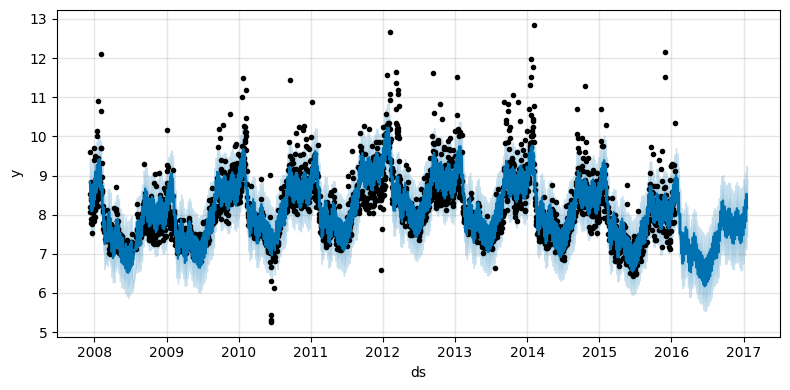

In [ ]:
# plt.figure(figsize=(8,4))
fig1 = m.plot(forecast, figsize=(8,4))

- If you want to see the forecast components, you can use the Prophet.plot_components method. By default you’ll see the trend, yearly seasonality, and weekly seasonality of the time series. If you include holidays, you’ll see those here, too.

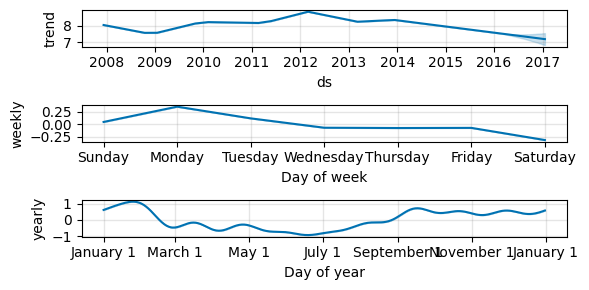

In [ ]:
fig2 = m.plot_components(forecast, figsize=(6,3))

- let's see the estimates and rel values altogether in a single graph

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


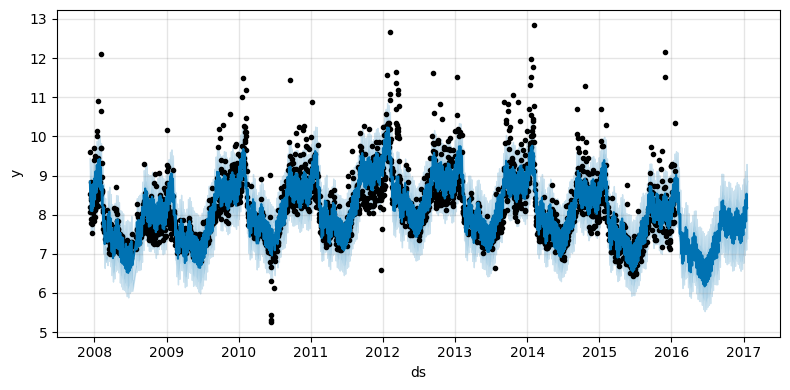

In [ ]:
m = Prophet()
m.fit(df)
future = m.make_future_dataframe(periods=365)
forecast = m.predict(future)
fig1 = m.plot(forecast, figsize=(8,4))

In [ ]:
predicted_df = forecast[['ds', 'yhat']]
pd.concat([predicted_df.head(3),predicted_df.tail(3)])

,ds,yhat
0,2007-12-10,8.844654
1,2007-12-11,8.593185
2,2007-12-12,8.389000
3267,2017-01-17,8.322571
3268,2017-01-18,8.155201
3269,2017-01-19,8.167158


In [ ]:
pd.concat([df.head(3),df.tail(3)])

,ds,y
0,2007-12-10,9.590761
1,2007-12-11,8.519590
2,2007-12-12,8.183677
2902,2016-01-18,10.333775
2903,2016-01-19,9.125871
2904,2016-01-20,8.891374


In [ ]:
df.dtypes , predicted_df.dtypes

(ds    datetime64[ns]
 y            float64
 dtype: object,
 ds      datetime64[ns]
 yhat           float64
 dtype: object)

In [ ]:
# Merge the actual and predicted DataFrames on the 'ds' column
merged_df = pd.merge(df, predicted_df, on='ds', how='outer')
pd.concat([merged_df.head(3), merged_df.tail(3)])

,ds,y,yhat
0,2007-12-10,9.590761,8.844654
1,2007-12-11,8.519590,8.593185
2,2007-12-12,8.183677,8.389000
3267,2017-01-17,NaN,8.322571
3268,2017-01-18,NaN,8.155201
3269,2017-01-19,NaN,8.167158


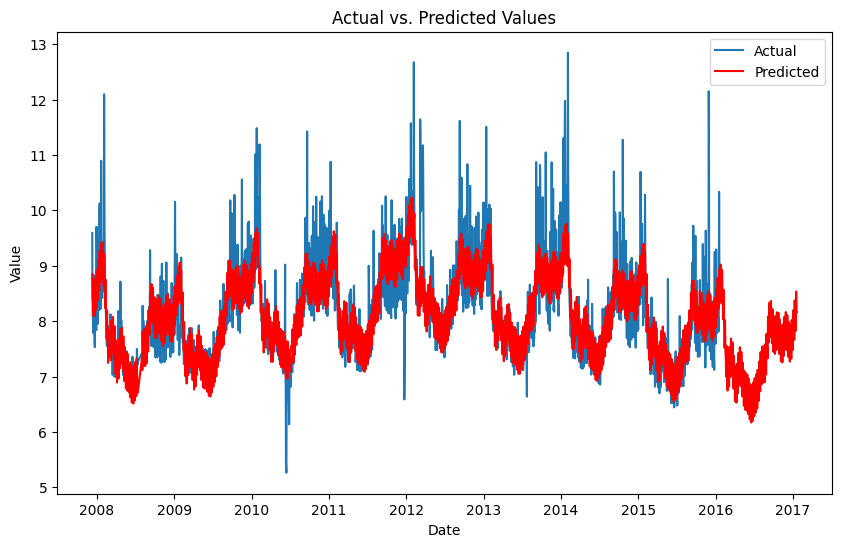

In [ ]:
# Plot the actual and predicted values
plt.figure(figsize=(10, 6))
plt.plot(merged_df['ds'], merged_df['y'], label='Actual')
plt.plot(merged_df['ds'], merged_df['yhat'], label='Predicted', color='red')
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.show()

## A simple comparison between ARIMA and RNN

In [1]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
import matplotlib.pyplot as plt

# Generate example time series data
np.random.seed(0)
time_series = np.cumsum(np.random.normal(0, 1, 100))

# Split data into training and testing sets
train_size = int(len(time_series) * 0.8)
train_data, test_data = time_series[:train_size], time_series[train_size:]


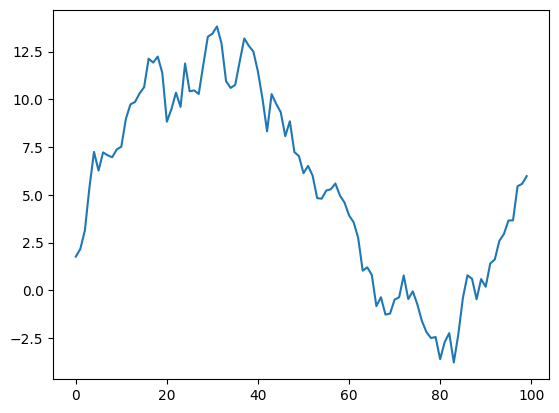

In [2]:
plt.plot(time_series)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


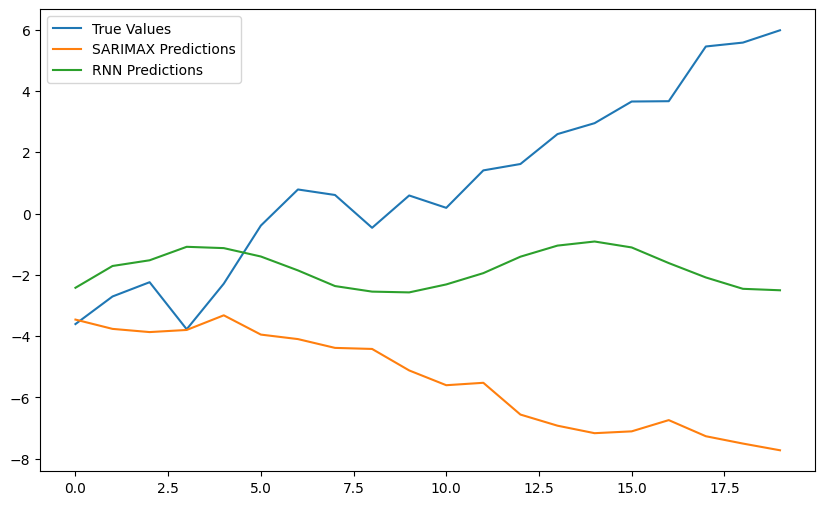

In [3]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input
import matplotlib.pyplot as plt

# Assuming time_series, train_data, test_data are already defined from previous cells

# SARIMAX Model
model_sarimax = SARIMAX(train_data, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
fit_sarimax = model_sarimax.fit(disp=0)
sarimax_predictions = fit_sarimax.predict(start=len(train_data), end=len(train_data)+len(test_data)-1, typ='levels')

# Scale data for RNN
scaler = MinMaxScaler()
train_data_scaled = scaler.fit_transform(train_data.reshape(-1, 1))
test_data_scaled = scaler.transform(test_data.reshape(-1, 1))

# Function to create sequences for RNN
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length)])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

seq_length = 10    # use 10 previous values to predict the next

# Prepare training data for RNN
if len(train_data_scaled) <= seq_length:
    raise ValueError("Training data is too short for the specified sequence length.")
X_train_rnn, y_train_rnn = create_sequences(train_data_scaled, seq_length)

# Create and train RNN model
def create_rnn_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        SimpleRNN(50, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

model_rnn = create_rnn_model((seq_length, 1)) # input_shape for SimpleRNN layer
model_rnn.fit(X_train_rnn, y_train_rnn, epochs=50, batch_size=1, verbose=0)

# Make predictions using RNN
# The initial input for prediction should be the last `seq_length` values from the training data
if len(train_data_scaled) < seq_length:
    raise ValueError("Training data is too short to form initial prediction sequence.")

current_sequence = train_data_scaled[-seq_length:] # Initial window for prediction
rnn_predictions = []

for _ in range(len(test_data)):
    # Reshape current_sequence for prediction: (1, seq_length, 1)
    # The batch size is 1, so we add an extra dimension at the beginning
    input_for_prediction = current_sequence.reshape(1, seq_length, 1)

    rnn_pred_scaled = model_rnn.predict(input_for_prediction, verbose=0)[0][0] # Get scalar prediction

    rnn_predictions.append(scaler.inverse_transform([[rnn_pred_scaled]])[0][0])

    # Update the sequence by removing the oldest value and adding the new prediction
    current_sequence = np.append(current_sequence[1:], [[rnn_pred_scaled]], axis=0)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(test_data, label='True Values')
plt.plot(sarimax_predictions, label='SARIMAX Predictions')
plt.plot(rnn_predictions, label='RNN Predictions')
plt.legend()
plt.show()

- SARIMAX (통계적 선형 모델)
  - 데이터의 양이 수개월~수년 정도로 비교적 적을 때: 딥러닝을 돌리기엔 턱없이 부족한 데이터셋에서도 통계적 안정성 덕분에 훌륭한 성능을 낸다.
  - 비즈니스적 설명이 필수적일 때: "이번 달 매출 예측이 왜 이렇게 나왔는가?"에 대해 "지난달 매출의 영향이 40%이고, 마케팅 비용(외부 변수)의 효과가 20% 반영되었다"와 같이 명확한 근거를 보고해야 할 때 유리하다.
  - 뚜렷한 주기가 존재할 때: 주간, 월간, 연간 등 계절성 주기가 명확한 도메인 데이터(예: 전력 수요, 계절 상품 매출)에서 매우 견고하게 작동한다.
  - 독립변수가 여러 개라도, 데이터가 소규모(수백 개 수준)이고 변수들 간의 관계가 비교적 명확하며 통계적인 설명(p-value)이 중요할 때.
- RNN/LSTM
  - 데이터가 초 단위, 분 단위로 쏟아지는 대용량일 때: 금융 고주파 데이터, 센서 IoT 데이터, 대규모 웹 트래픽 등 데이터의 양이 방대할 때 딥러닝의 진가가 발휘된다.
  - 패턴이 고정적이지 않고 복잡할 때: 선형적인 추세나 고정된 계절성 주기로는 도저히 설명할 수 없는 급격한 변동이나 텍스트/이미지 등 다른 형태의 sequential 데이터와 결합하여 예측해야 할 때 적합하다.
  - 다변량 예측(Multivariate Forecasting)이 중심일 때: 여러 개의 서로 영향을 주고받는 시계열 변수들을 동시에 입력하여 여러 개의 예측값을 동시에 뽑아내야 할 때 구조적으로 훨씬 유연하다.
  - 독립변수가 여러 개이면서 데이터의 양이 방대하고, 변수 간의 관계가 매우 복잡·비선형적이며, 여러 결과값을 동시에 예측해야 할 때.